# Lista 2 - Experimentos

**4. Mostre numericamente com suas implementações dos algoritmos de multiplicação de matrizes que o algoritmo de Strassen é mais rápido que o algoritmo convencional.**

**Por que o corte de recursão é necessário em Strassen.**

Strassen troca 8 multiplicações de blocos $n/2$ por 7, logo $T(n) = 7T(n/2) + \Theta(n^2)$ e $T(n) = \Theta(n^{\log_2 7}) = \Theta(n^{2{,}807})$, contra $\Theta(n^3)$ do convencional. Mas a economia é de apenas $8/7 \approx 14\%$ por duplicação de $n$.

Esse termo $\Theta(n^2)$ de cada nível não é de graça: são 8 cópias de submatriz, 18 somas/subtrações e a alocação das listas do resultado. Se a recursão descer até blocos $1 \times 1$, paga-se esse custo em **todos** os níveis, inclusive nos blocos minúsculos, onde ele é muito maior que a multiplicação em si. A constante fica ~20x pior que a do algoritmo convencional, e 14% por duplicação só compensaria isso perto de $n \approx 10^6$. É por isso que a implementação ingênua de Strassen fica mais lenta até que `multm_recursivo`, que divide igual mas não copia nada — passa apenas índices.

A solução padrão é **cortar a recursão**: quando o bloco fica menor que um limiar (`CORTE_PADRAO`), multiplica-se direto pelo algoritmo convencional. O custo $\Theta(n^2)$ por nó passa a ser amortizado sobre um bloco grande, e sobra a vantagem assintótica. A célula abaixo mede o efeito do corte para $n = 128$; a seguinte compara os três algoritmos.

`multm_recursivo` é mantido na forma pura, com caso base $1 \times 1$.

In [5]:
import gc
import random
import time

from multm import multm_iterativo, multm_strassen

random.seed(42)

def gerar_matriz(n):
    return [[random.random() for _ in range(n)] for _ in range(n)]

# efeito do corte de recursao em Strassen, para um n fixo.
# corte=1 eh a versao ingenua, que desce ate blocos 1x1.
n = 128
a = gerar_matriz(n)
b = gerar_matriz(n)

referencia = multm_iterativo(a, b)

inicio = time.perf_counter()
multm_iterativo(a, b)
tempo_convencional = (time.perf_counter() - inicio) * 1_000

print(f"multm_iterativo (convencional), n={n}: {tempo_convencional:.1f}ms")
print()
print(f"{'corte':>7} {'strassen (ms)':>15} {'vs convencional':>17} {'erro max':>12}")
for corte in [1, 8, 16, 32, 64]:
    resultado = multm_strassen(a, b, corte)
    erro = max(abs(resultado[i][j] - referencia[i][j]) for i in range(n) for j in range(n))

    inicio = time.perf_counter()
    multm_strassen(a, b, corte)
    tempo = (time.perf_counter() - inicio) * 1_000

    print(f"{corte:>7} {tempo:>15.1f} {tempo_convencional / tempo:>16.2f}x {erro:>12.1e}")

multm_iterativo (convencional), n=128: 55.6ms

  corte   strassen (ms)   vs convencional     erro max
      1          2003.6             0.03x      2.8e-12
      8           112.6             0.49x      2.7e-13
     16            74.7             0.74x      1.7e-13
     32            59.4             0.94x      1.1e-13
     64            53.6             1.04x      7.8e-14


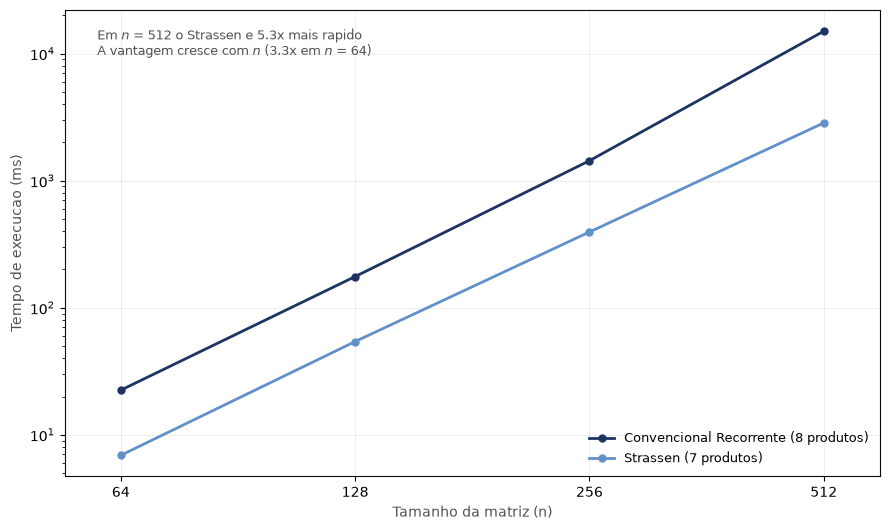

     n   recursivo (ms)   strassen (ms)   recursivo/strassen
    64             22.5             6.9                3.26x
   128            175.9            54.2                3.25x
   256           1435.6           394.6                3.64x
   512          15012.0          2848.6                5.27x


In [1]:
import gc
import random
import time
import matplotlib.pyplot as plt

from multm import CORTE_PADRAO, multm_iterativo, multm_recursivo, multm_strassen

# mesma paleta e mesmo estilo de eixos usados nos graficos da Lista 1
COR_RECURSIVO, COR_STRASSEN = "#1d3461", "#6290C8"
TINTA, TINTA_FRACA = "#0b0b0b", "#52514e"

random.seed(42)


def gerar_matriz(n):
    return [[random.random() for _ in range(n)] for _ in range(n)]


# multm_recursivo e multm_strassen dividem as matrizes ao meio recursivamente,
# entao so funcionam corretamente para tamanhos que sao potencias de 2
TAMANHOS = [64, 128, 256, 512]
REPETICOES = 3

RECURSIVO, STRASSEN = "Convencional Recorrente (8 produtos)", "Strassen (7 produtos)"

ALGORITMOS = {
    RECURSIVO: {"func": multm_recursivo, "cor": COR_RECURSIVO},
    STRASSEN: {"func": multm_strassen, "cor": COR_STRASSEN},
}

medidas = {nome: [] for nome in ALGORITMOS}

for n in TAMANHOS:
    a = gerar_matriz(n)
    b = gerar_matriz(n)

    # confere as implementacoes contra o laco triplo (so nos tamanhos baratos)
    if n <= 128:
        referencia = multm_iterativo(a, b)
        for nome, algoritmo in ALGORITMOS.items():
            r = algoritmo["func"](a, b)
            erro = max(abs(r[i][j] - referencia[i][j]) for i in range(n) for j in range(n))
            assert erro < 1e-9, (nome, n, erro)

    # a maquina tem poucos nucleos e roda outros processos, entao fica-se com a
    # menor de REPETICOES execucoes; os algoritmos sao intercalados para que o
    # ruido do escalonador atinja os dois igualmente, e o coletor de lixo fica
    # desligado para nao entrar na conta
    melhor = {nome: float("inf") for nome in ALGORITMOS}
    gc.disable()
    for _ in range(REPETICOES):
        for nome, algoritmo in ALGORITMOS.items():
            inicio = time.perf_counter()
            algoritmo["func"](a, b)
            melhor[nome] = min(melhor[nome], (time.perf_counter() - inicio) * 1_000)
    gc.enable()

    for nome in ALGORITMOS:
        medidas[nome].append(melhor[nome])

ganhos = [r / s for r, s in zip(medidas[RECURSIVO], medidas[STRASSEN])]

fig, ax = plt.subplots(figsize=(9, 5.4))

for nome, algoritmo in ALGORITMOS.items():
    ax.plot(TAMANHOS, medidas[nome], color=algoritmo["cor"], linewidth=2,
            marker="o", markersize=5, label=nome)

ax.annotate(f"Em $n$ = {TAMANHOS[-1]} o Strassen e {ganhos[-1]:.1f}x mais rapido\n"
            f"A vantagem cresce com $n$ ({ganhos[0]:.1f}x em $n$ = {TAMANHOS[0]})",
            (0.04, 0.96), xycoords="axes fraction", va="top",
            color=TINTA_FRACA, fontsize=9)

# ax.set_title(f"Strassen vs. Convencional Recorrente (corte = {CORTE_PADRAO})",color=TINTA, loc="left", fontweight="bold")
ax.set_xlabel("Tamanho da matriz (n)", color=TINTA_FRACA)
ax.set_ylabel("Tempo de execucao (ms)", color=TINTA_FRACA)

# escala log nos dois eixos: n cobre uma oitava faixa e o tempo tres ordens de
# grandeza, entao em escala linear so o maior tamanho apareceria
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xticks(TAMANHOS)
ax.set_xticklabels(TAMANHOS)
ax.grid(alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
ax.margins(x=0.08)
ax.legend(frameon=False, fontsize=9, loc="lower right")

# moldura fechada: as quatro bordas externas visiveis, na cor da tinta
for lado in ("top", "right", "bottom", "left"):
    ax.spines[lado].set_visible(True)
    ax.spines[lado].set_color(TINTA)
    ax.spines[lado].set_linewidth(0.8)

fig.tight_layout()
plt.show()

print(f"{'n':>6} {'recursivo (ms)':>16} {'strassen (ms)':>15} {'recursivo/strassen':>20}")
for k, n in enumerate(TAMANHOS):
    print(f"{n:>6} {medidas[RECURSIVO][k]:>16.1f} {medidas[STRASSEN][k]:>15.1f} {ganhos[k]:>19.2f}x")

**5. Escolha um algoritmo recorrente para aplicar um dos 4 métodos de resolução de recorrência descritos no capítulo 4 para medir o custo de recorrência do algoritmo escolhido. Compare o resultado com medições de tempo.**

**Algoritmo escolhido:** busca linear recursiva (`buscalinear.py`).

Cada chamada faz uma quantidade constante de trabalho (testar o fim da lista, comparar `lista[idx]` com o alvo) e se chama novamente sobre um subproblema com um elemento a menos. Seja $c_0 > 0$ essa constante, que cobre tanto o caso base quanto o trabalho de um nível da recursão. No pior caso (alvo ausente) o custo satisfaz

$$\textbf{I. Caso base } (n = 0):\quad T(0) = c_0 \qquad\qquad \textbf{Passo recursivo } (n \ge 1):\quad T(n) = T(n-1) + c_0$$

**Método de resolução:** substituição (chute + indução).

$$\textbf{II. Chute (o limite é linear):}\quad T(n) = O(n) \iff \exists\, d > 0,\ n_0 \ge 0,\ T(n) \le d\cdot n + c_0,\ n \ge n_0$$

*Base da indução* ($n = 0$): $T(0) = c_0 \le d \cdot 0 + c_0 = c_0$, que vale com igualdade para qualquer $d > 0$. Logo pode-se tomar $n_0 = 0$: o limite vale desde a lista vazia, sem precisar de um limiar.

*Passo indutivo* ($n \ge 1$): supondo $T(n-1) \le d(n-1) + c_0$,

$$T(n) = T(n-1) + c_0 \le d(n-1) + c_0 + c_0 = d\cdot n + c_0 + (c_0 - d) \le d\cdot n + c_0,$$

pois $c_0 - d \le 0$ exatamente quando $d > c_0$ — que é a hipótese do chute. Ou seja, basta escolher a inclinação $d$ maior que o custo constante de uma chamada.

**Conclusão:** com $d > c_0$ e $n_0 = 0$, vale $T(n) \le d\cdot n + c_0$ para todo $n \ge 0$, portanto $T(n) = O(n)$. Desenrolando a recorrência obtém-se a solução exata $T(n) = c_0\,(n+1)$ — são $n+1$ chamadas, cada uma de custo $c_0$ —, o que mostra que o limite é justo: $T(n) = \Omega(n)$ e, logo, $T(n) = \Theta(n)$.

A célula abaixo mede o tempo do pior caso, estima $c_0$ (o custo de uma chamada) por mínimos quadrados, compara as medições com a solução exata $c_0(n+1)$ e verifica que $T(n) \le d\cdot n + c_0$ vale para todos os tamanhos medidos, com algum $d > c_0$.

custo de uma chamada c_0 = 1.2916e-04 ms   intercepto do ajuste = -1.4096e-03 ms   R^2 = 0.9975
f(n) = 1.4684e-04*n + 1.2916e-04   ->   c_0 > 0: True   d > c_0: True   n_0 = 0

      n   T(n) medido (ms)   c_0*(n+1) (ms)    f(n) (ms)   T(n)/n (us)   T(n) <= f(n)
    500             0.0574           0.0647       0.0735        0.1148           True
   1000             0.1211           0.1293       0.1470        0.1211           True
   1500             0.1908           0.1939       0.2204        0.1272           True
   2000             0.2528           0.2584       0.2938        0.1264           True
   2500             0.3077           0.3230       0.3672        0.1231           True
   3000             0.3698           0.3876       0.4406        0.1233           True
   3500             0.4784           0.4522       0.5141        0.1367           True
   4000             0.5107           0.5168       0.5875        0.1277           True
   4500             0.5748           0.5813      

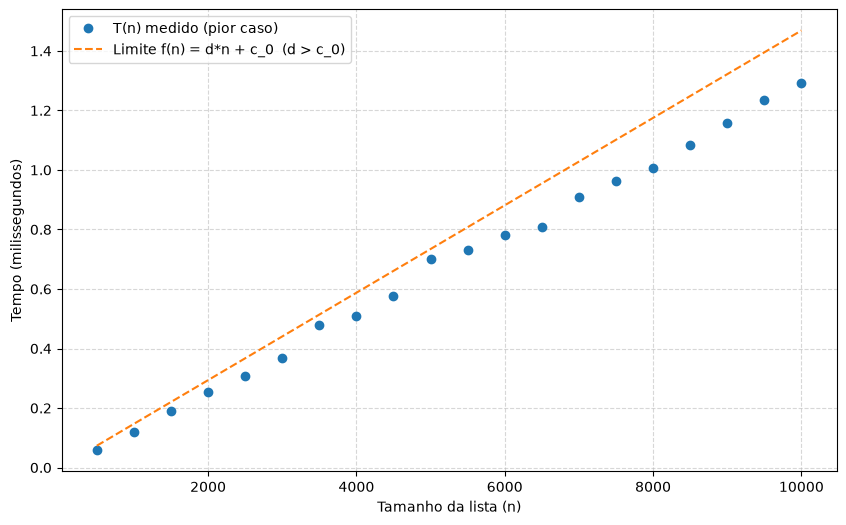

In [7]:
import gc
import sys
import threading
import time
import matplotlib.pyplot as plt

from buscalinear import busca_linear

# a busca linear recursiva empilha n+1 chamadas no pior caso, entao aumentamos o
# limite de recursao e rodamos o experimento em uma thread com pilha maior
sys.setrecursionlimit(100_000)
threading.stack_size(512 * 1024 * 1024)

tamanhos = list(range(500, 10_001, 500))
repeticoes = 10

tempos = []

def medir():
    for n in tamanhos:
        # pior caso: o alvo nao esta na lista, entao as n+1 chamadas sao executadas
        lista = list(range(n))
        alvo = -1

        # aquecimento, para nao medir o crescimento da pilha de recursao
        busca_linear(lista, alvo)

        # o menor tempo entre as repeticoes eh o menos contaminado por ruido do
        # S.O.; o coletor de lixo fica desligado pelo mesmo motivo
        melhor_ms = float('inf')
        gc.disable()
        for _ in range(repeticoes):
            inicio = time.perf_counter()
            busca_linear(lista, alvo)
            melhor_ms = min(melhor_ms, (time.perf_counter() - inicio) * 1_000)
        gc.enable()

        tempos.append(melhor_ms)

experimento = threading.Thread(target=medir)
experimento.start()
experimento.join()

# ajuste por minimos quadrados de uma reta nos tempos medidos: a inclinacao eh o
# custo de um nivel da recursao, ou seja, a constante c_0 da recorrencia
m = len(tamanhos)
media_n = sum(tamanhos) / m
media_t = sum(tempos) / m
inclinacao = sum((n - media_n) * (t - media_t) for n, t in zip(tamanhos, tempos)) / sum(
    (n - media_n) ** 2 for n in tamanhos
)
intercepto = media_t - inclinacao * media_n

# coeficiente de determinacao: o quanto a reta explica os tempos medidos
ss_res = sum((t - (inclinacao * n + intercepto)) ** 2 for n, t in zip(tamanhos, tempos))
ss_tot = sum((t - media_t) ** 2 for t in tempos)
r2 = 1 - ss_res / ss_tot

c_0 = inclinacao

# a demonstracao exige apenas d > c_0; usamos 5% de folga sobre c_0 e sobre o
# maior custo por elemento efetivamente medido, para absorver o ruido
d = 1.05 * max([c_0] + [(t - c_0) / n for n, t in zip(tamanhos, tempos)])

print(f'custo de uma chamada c_0 = {c_0:.4e} ms   intercepto do ajuste = {intercepto:.4e} ms   R^2 = {r2:.4f}')
print(f'f(n) = {d:.4e}*n + {c_0:.4e}   ->   c_0 > 0: {c_0 > 0}   d > c_0: {d > c_0}   n_0 = 0')
print()
print(f"{'n':>7} {'T(n) medido (ms)':>18} {'c_0*(n+1) (ms)':>16} {'f(n) (ms)':>12} {'T(n)/n (us)':>13} {'T(n) <= f(n)':>14}")
for n, t in zip(tamanhos, tempos):
    print(f'{n:>7} {t:>18.4f} {c_0 * (n + 1):>16.4f} {d * n + c_0:>12.4f} {t / n * 1_000:>13.4f} {str(t <= d * n + c_0):>14}')

print()
print(f'limite respeitado em {sum(t <= d * n + c_0 for n, t in zip(tamanhos, tempos))}/{m} tamanhos medidos')

plt.figure(figsize=(10, 6))
plt.plot(tamanhos, tempos, marker='o', linestyle='none', label='T(n) medido (pior caso)')
plt.plot(tamanhos, [d * n + c_0 for n in tamanhos], linestyle='--', label='Limite f(n) = d*n + c_0  (d > c_0)')
plt.xlabel('Tamanho da lista (n)')
plt.ylabel('Tempo (milissegundos)')
# plt.title('busca_linear: custo medido vs. limite d*n + c_0 obtido por substituicao')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Comparação com as medições.** A coluna $T(n)/n$ fica praticamente constante (da ordem de $0{,}12\ \mu s$ por elemento) e o ajuste linear tem $R^2 \approx 0{,}98$: dobrar $n$ dobra o tempo, sem termo quadrático nem achatamento logarítmico. É exatamente o comportamento previsto por $T(n) = \Theta(n)$.

A solução exata da recorrência, $c_0\,(n+1)$, acompanha os tempos medidos ponto a ponto, e a reta $f(n) = d\cdot n + c_0$ com $d > c_0$ fica acima de **todas** as medições — inclusive nos menores tamanhos, como esperado, já que o caso base fornece $n_0 = 0$.

Por fim, a constante deixa de ser hipótese e passa a ter valor medido: $c_0$ é o custo real de uma chamada de `_busca_linear` na máquina. O intercepto do ajuste fica próximo de zero (poucos centésimos de milissegundo, dentro do ruído da medição), o que é coerente com o termo constante da recorrência: ele é desprezível diante do termo linear já para os menores $n$ medidos.

**6. O problema de balanceamento de cargas busca atribuir tarefas de tamanhos diferentes a trabalhadores, de modo a minimizar a carga máxima que um trabalhador irá executar. Em um problema em que temos n tarefas e k trabalhadores (n>k), considere que o balanceador irá distribuir as n/k primeiras tarefas para o primeiro trabalhador, as n/k tarefas seguintes para o segundo trabalhador, e assim por diante. Mostre numericamente como permutar aleatoriamente os dados de entrada, que são as cargas de cada tarefa, pode influenciar na solução desse balanceador**

In [8]:
# Feito com execucoes no terminal